# 15 - Predicting LLM Disagreement From Text Alone

This notebook asks whether disagreement among six zero-shot LLM stance labels is itself predictable from text.

We compare **three dictionary baselines**, **TF-IDF**, and **DeBERTa/BERT** on four targets:

1. `split` - binary disagreement on neutral vs stanced
2. `p_directional` - share of models calling the turn directional
3. `score_std_3way` - dispersion on the collapsed dove / neutral / hawk scale
4. `score_std_5way` - dispersion on the full 5-class stance scale

The dictionaries are:

1. **Loughran-McDonald style sentiment baseline**
2. **Simple hawk / dove / uncertainty dictionary**
3. **Parle-style topic x modifier dictionary**

The modeling logic is the same throughout:

- input: turn text
- labels: disagreement targets derived from the six LLM votes
- evaluation: grouped train / test split by `doc_id`

So the dictionary models are **not** trying to recreate the original 5-class labels.  
They are trying to predict the disagreement objects built from those labels.

In [1]:
from __future__ import annotations

import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, ShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", font_scale=0.95)

In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path("/content")
else:
    ROOT = Path("..")

OUTPUT_DIR = ROOT / "output" / "stance"
INPUT_FILES = {
    "deepseekv3": OUTPUT_DIR / "turn_predictions_deepseekv3.csv",
    "gemini25flash": OUTPUT_DIR / "turn_predictions_gemini25flash.csv",
    "gpt-4o": OUTPUT_DIR / "turn_predictions_gpt-4o.csv",
    "llama33": OUTPUT_DIR / "turn_predictions_llama33.csv",
    "mistrallarge_or": OUTPUT_DIR / "turn_predictions_mistrallarge_or.csv",
    "qwen25_72b": OUTPUT_DIR / "turn_predictions_qwen25_72b.csv",
}
MERGED_TARGET_PATH = OUTPUT_DIR / "turn_disagreement_targets.csv"
SPLIT_PATH = OUTPUT_DIR / "disagreement_doc_split.csv"

LABEL_SCORE_3WAY = {
    "dovish": -1,
    "mostly dovish": -1,
    "neutral": 0,
    "mostly hawkish": 1,
    "hawkish": 1,
}
LABEL_SCORE_5WAY = {
    "dovish": -2,
    "mostly dovish": -1,
    "neutral": 0,
    "mostly hawkish": 1,
    "hawkish": 2,
}
STANCED = {"dovish", "mostly dovish", "mostly hawkish", "hawkish"}

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS_CV = 5

## 1. Load or build the disagreement dataset

In Colab, the simplest upload set is:

- `turn_disagreement_targets.csv`
- `disagreement_doc_split.csv`

If the merged file is missing or stale, the notebook rebuilds from the six raw turn CSVs.

In [3]:
meta_cols = [
    "turn_uid",
    "bank",
    "doc_id",
    "date",
    "doc_type",
    "speaker",
    "speaker_role",
    "turn_idx",
    "text",
]

def build_disagreement_from_raw() -> pd.DataFrame:
    frames = []
    for model_key, path in INPUT_FILES.items():
        if not path.exists():
            raise FileNotFoundError(f"Missing raw input file: {path}")
        df = pd.read_csv(path)
        df["label"] = df["label"].astype(str).str.strip().str.lower()
        keep = df[meta_cols + ["label"]].copy()
        keep = keep.rename(columns={"label": f"label_{model_key}"})
        frames.append(keep)

    merged = frames[0]
    for frame in frames[1:]:
        merged = merged.merge(frame, on=meta_cols, how="inner")

    label_cols = [c for c in merged.columns if c.startswith("label_")]
    model_keys = [c.replace("label_", "") for c in label_cols]
    score3_cols = []
    score5_cols = []
    stanced_cols = []

    for model_key in model_keys:
        c3 = f"score3_{model_key}"
        c5 = f"score5_{model_key}"
        cs = f"stanced_{model_key}"
        merged[c3] = merged[f"label_{model_key}"].map(LABEL_SCORE_3WAY)
        merged[c5] = merged[f"label_{model_key}"].map(LABEL_SCORE_5WAY)
        merged[cs] = merged[f"label_{model_key}"].isin(STANCED)
        score3_cols.append(c3)
        score5_cols.append(c5)
        stanced_cols.append(cs)

    merged["n_models"] = len(model_keys)
    merged["n_stanced"] = merged[stanced_cols].sum(axis=1)
    merged["split"] = ((merged["n_stanced"] > 0) & (merged["n_stanced"] < len(model_keys))).astype(int)
    merged["p_directional"] = merged["n_stanced"] / len(model_keys)
    merged["n_unique_labels"] = merged[label_cols].nunique(axis=1)
    merged["sign_conflict"] = (
        merged[score3_cols].eq(-1).any(axis=1) & merged[score3_cols].eq(1).any(axis=1)
    ).astype(int)
    merged["score_std_3way"] = merged[score3_cols].std(axis=1, ddof=0)
    merged["score_std_5way"] = merged[score5_cols].std(axis=1, ddof=0)
    merged["text"] = merged["text"].astype(str)
    merged["word_count"] = merged["text"].str.findall(r"\b\w+\b").str.len()
    merged["char_count"] = merged["text"].str.len()
    merged["sentence_count"] = merged["text"].str.count(r"[\.!?]") + 1
    return merged.sort_values(["doc_id", "turn_idx", "turn_uid"]).reset_index(drop=True)

needed = {"split", "p_directional", "score_std_3way", "score_std_5way", "doc_id", "text"}
if MERGED_TARGET_PATH.exists():
    disagreement = pd.read_csv(MERGED_TARGET_PATH)
    if not needed.issubset(disagreement.columns):
        disagreement = build_disagreement_from_raw()
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        disagreement.to_csv(MERGED_TARGET_PATH, index=False)
        source_used = f"stale merged file rebuilt from raw files -> {MERGED_TARGET_PATH}"
    else:
        source_used = f"merged file: {MERGED_TARGET_PATH}"
else:
    disagreement = build_disagreement_from_raw()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    disagreement.to_csv(MERGED_TARGET_PATH, index=False)
    source_used = f"rebuilt from raw files and saved -> {MERGED_TARGET_PATH}"

print(source_used)
summary = {
    "rows": len(disagreement),
    "meetings": disagreement["doc_id"].nunique(),
    "split_rate": disagreement["split"].mean(),
    "p_directional_mean": disagreement["p_directional"].mean(),
    "score_std_3way_mean": disagreement["score_std_3way"].mean(),
    "score_std_5way_mean": disagreement["score_std_5way"].mean(),
}
print(pd.Series(summary).to_string())
disagreement.head(3)

merged file: ..\output\stance\turn_disagreement_targets.csv
rows                   3972.000000
meetings                206.000000
split_rate                0.313696
p_directional_mean        0.239426
score_std_3way_mean       0.159348
score_std_5way_mean       0.194706


,turn_uid,bank,doc_id,date,doc_type,speaker,speaker_role,turn_idx,text,label_deepseekv3,label_gemini25flash,label_gpt-4o,label_llama33,label_mistrallarge_or,label_qwen25_72b,score3_deepseekv3,score5_deepseekv3,stanced_deepseekv3,score3_gemini25flash,score5_gemini25flash,stanced_gemini25flash,score3_gpt-4o,score5_gpt-4o,stanced_gpt-4o,score3_llama33,score5_llama33,stanced_llama33,score3_mistrallarge_or,score5_mistrallarge_or,stanced_mistrallarge_or,score3_qwen25_72b,score5_qwen25_72b,stanced_qwen25_72b,n_models,n_stanced,split,p_directional,n_unique_labels,sign_conflict,score_mean_3way,score_std_3way,score_mean_5way,score_std_5way,score_range_5way,word_count,char_count,sentence_count
0,BoE_201502_transcript_1,BoE,BoE_201502_transcript,201502,transcript,Mark Carney,governor,1,"Well, recognising that this is a hypothetical question, you know, would a change in Greece's position have an impact on the forecast? Yes. Would it have the...",neutral,neutral,neutral,neutral,neutral,neutral,0,0,False,0,0,False,0,0,False,0,0,False,0,0,False,0,0,False,6,0,0,0.0,1,0,0.0,0.0,0.0,0.0,0,379,2142,19
1,BoE_201502_transcript_3,BoE,BoE_201502_transcript,201502,transcript,Mark Carney,governor,3,"Well, as you know, Jennifer, we don't do real time updating of our inflation forecast. The next one's due in the middle of May, I think. Yeah, we get three ...",neutral,neutral,neutral,neutral,neutral,neutral,0,0,False,0,0,False,0,0,False,0,0,False,0,0,False,0,0,False,6,0,0,0.0,1,0,0.0,0.0,0.0,0.0,0,85,433,5
2,BoE_201502_transcript_5,BoE,BoE_201502_transcript,201502,transcript,Mark Carney,governor,5,"Look - markets will - I think - let me go back to something I said at my opening remarks, which is that what markets have been doing since our last forecast...",mostly hawkish,mostly hawkish,mostly hawkish,mostly hawkish,mostly hawkish,mostly hawkish,1,1,True,1,1,True,1,1,True,1,1,True,1,1,True,1,1,True,6,6,0,1.0,1,0,1.0,0.0,1.0,0.0,0,289,1638,10


## 2. Target distributions

We keep both boundary-style disagreement and continuous dispersion targets because they answer slightly different questions:

- `split` and `p_directional` focus on whether the turn crosses the stance threshold at all
- `score_std_3way` and `score_std_5way` summarize broader instability in the panel of labels

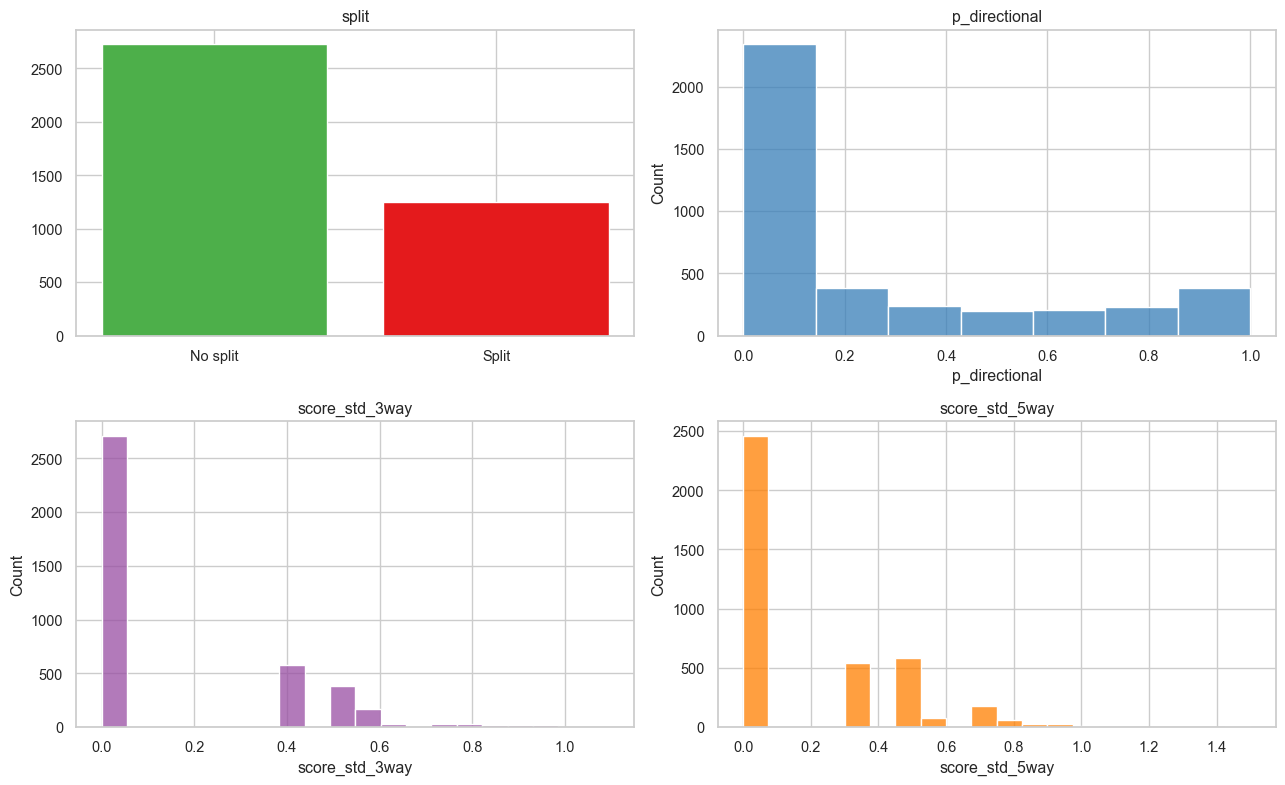

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

split_counts = disagreement["split"].map({0: "No split", 1: "Split"}).value_counts()
axes[0, 0].bar(split_counts.index, split_counts.values, color=["#4daf4a", "#e41a1c"])
axes[0, 0].set_title("split")

sns.histplot(disagreement["p_directional"], bins=np.linspace(0, 1, 8), ax=axes[0, 1], color="#377eb8")
axes[0, 1].set_title("p_directional")

sns.histplot(disagreement["score_std_3way"], bins=20, ax=axes[1, 0], color="#984ea3")
axes[1, 0].set_title("score_std_3way")

sns.histplot(disagreement["score_std_5way"], bins=20, ax=axes[1, 1], color="#ff7f00")
axes[1, 1].set_title("score_std_5way")

plt.tight_layout()
plt.show()

## 3. Grouped split by `doc_id`

All headline results use a leakage-safe grouped train / test split by meeting.

In [5]:
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(disagreement, groups=disagreement["doc_id"]))

train_df = disagreement.iloc[train_idx].reset_index(drop=True)
test_df = disagreement.iloc[test_idx].reset_index(drop=True)

train_doc_ids = set(train_df["doc_id"])
test_doc_ids = set(test_df["doc_id"])
assert train_doc_ids.isdisjoint(test_doc_ids)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
split_export = pd.DataFrame(
    {
        "doc_id": sorted(disagreement["doc_id"].unique()),
        "split": ["test" if doc_id in test_doc_ids else "train" for doc_id in sorted(disagreement["doc_id"].unique())],
    }
)
split_export.to_csv(SPLIT_PATH, index=False)

print(f"Train turns: {len(train_df):,} | Test turns: {len(test_df):,}")
print(f"Train meetings: {train_df['doc_id'].nunique()} | Test meetings: {test_df['doc_id'].nunique()}")

Train turns: 3,113 | Test turns: 859
Train meetings: 164 | Test meetings: 42


## 4. Dictionary representations

We compare three fixed dictionary representations:

1. **LM-style** generic finance sentiment proxy
2. **Simple hawk / dove / uncertainty** central-bank dictionary
3. **Parle-style** topic x modifier rule

These are transparent baselines, not replacement labelers.  
For comparability with TF-IDF and BERT, we fit simple downstream models on top of each fixed dictionary representation.

In [6]:
token_pattern = re.compile(r"\b[a-zA-Z][a-zA-Z\-']+\b")

def tokenize(text: str) -> list[str]:
    return token_pattern.findall(str(text).lower())

# 1. Lightweight LM-style proxy.
lm_positive = {
    "beneficial", "confidence", "efficient", "improve", "improved", "improvement",
    "improving", "opportunity", "profit", "profits", "rebound", "resilient",
    "robust", "stabilized", "stability", "strong", "stronger"
}
lm_negative = {
    "adverse", "decline", "declined", "declining", "declines", "deterioration",
    "difficult", "downturn", "loss", "losses", "pressure", "pressures",
    "recession", "risk", "risks", "stress", "uncertain", "uncertainty",
    "volatile", "volatility", "weak", "weakened", "weaker"
}

# 2. Simple central-bank hawk / dove / uncertainty dictionary.
simple_hawk = {
    "inflation", "inflationary", "restrictive", "tighten", "tightening", "raise",
    "higher", "upside", "overheating", "wage", "wages", "pressures", "rates"
}
simple_dove = {
    "support", "purchase", "purchases", "accommodative", "easing", "ease",
    "slowdown", "downside", "weaker", "unemployment", "cut", "lower", "stimulus"
}
simple_uncertain = {
    "uncertain", "uncertainty", "risk", "risks", "may", "might", "could", "perhaps",
    "possible", "depending", "conditional", "gradual", "careful", "monitor", "watch"
}

# 3. Parle-style topic x modifier.
parle_hawk_topic = {
    "business", "businesses", "demand", "economic", "economy", "employment", "energy",
    "equities", "equity", "expansion", "financial", "growth", "housing", "income",
    "indicators", "inflation", "inflationary", "investment", "investments", "labour",
    "manufacturing", "outlook", "output", "price", "prices", "production", "recovery",
    "resource", "securities", "slack", "spending", "target", "wage", "wages"
}
parle_dove_topic = {"accommodation", "devastation", "downturn", "recession", "unemployment"}
parle_positive = {
    "abating", "accelerated", "advance", "advanced", "better", "boom", "booming", "boost",
    "boosted", "eased", "elevated", "expand", "expanding", "faster", "firmer", "gains",
    "growing", "high", "higher", "improved", "improvement", "increase", "increased",
    "increases", "increasing", "raise", "rapid", "recovering", "rise", "risen", "rising",
    "robust", "strong", "stronger", "supportive", "up", "upside", "uptick"
}
parle_negative = {
    "adverse", "below", "constrained", "contract", "contracting", "contraction", "cooling",
    "decline", "declined", "declines", "declining", "decrease", "decreases", "decreasing",
    "depressed", "deteriorated", "deterioration", "down", "downbeat", "downside", "drop",
    "fall", "fallen", "falling", "fell", "insufficient", "less", "low", "lower", "moderated",
    "moderating", "reduce", "reduced", "restraint", "slack", "slow", "slowed", "slower",
    "slowing", "sluggish", "soft", "softened", "stress", "subdued", "turmoil",
    "underutilization", "volatile", "vulnerable", "weak", "weakened", "weaker", "weakness"
}

sentence_splitter = re.compile(r"(?<=[\.!?])\s+")

def lm_features(text: str) -> dict:
    toks = tokenize(text)
    n = max(len(toks), 1)
    pos = sum(t in lm_positive for t in toks)
    neg = sum(t in lm_negative for t in toks)
    return {
        "lm_pos": pos,
        "lm_neg": neg,
        "lm_net": pos - neg,
        "lm_pos_share": pos / n,
        "lm_neg_share": neg / n,
    }

def simple_cb_features(text: str) -> dict:
    toks = tokenize(text)
    n = max(len(toks), 1)
    hawk = sum(t in simple_hawk for t in toks)
    dove = sum(t in simple_dove for t in toks)
    uncertain = sum(t in simple_uncertain for t in toks)
    return {
        "cb_hawk": hawk,
        "cb_dove": dove,
        "cb_uncertain": uncertain,
        "cb_net": hawk - dove,
        "cb_hawk_share": hawk / n,
        "cb_dove_share": dove / n,
        "cb_uncertain_share": uncertain / n,
    }

def parle_sentence_score(sentence: str):
    toks = tokenize(sentence)
    hawk = sum(t in parle_hawk_topic for t in toks)
    dove = sum(t in parle_dove_topic for t in toks)
    pos = sum(t in parle_positive for t in toks)
    neg = sum(t in parle_negative for t in toks)
    if hawk == 0 and dove == 0:
        return None
    if hawk > dove and pos > neg:
        return 1
    if hawk > dove and pos < neg:
        return -1
    if hawk < dove and pos < neg:
        return 1
    if hawk < dove and pos > neg:
        return -1
    return 0

def parle_features(text: str) -> dict:
    sentences = [s.strip() for s in sentence_splitter.split(str(text)) if s.strip()]
    scores = [parle_sentence_score(s) for s in sentences]
    valid = [s for s in scores if s is not None]
    j = len(valid)
    hdi = 0.0 if j == 0 else 100.0 * sum(valid) / j
    return {
        "parle_hdi": hdi,
        "parle_relevant_sentences": j,
    }

def build_dict_frame(texts: pd.Series, builder) -> pd.DataFrame:
    return pd.DataFrame([builder(text) for text in texts.astype(str)])

dict_frames_train = {
    "LM": build_dict_frame(train_df["text"], lm_features),
    "SimpleCB": build_dict_frame(train_df["text"], simple_cb_features),
    "Parle": build_dict_frame(train_df["text"], parle_features),
}
dict_frames_test = {
    "LM": build_dict_frame(test_df["text"], lm_features),
    "SimpleCB": build_dict_frame(test_df["text"], simple_cb_features),
    "Parle": build_dict_frame(test_df["text"], parle_features),
}

for name, frame in dict_frames_train.items():
    print(name, frame.head(2).to_dict(orient="records"))

LM [{'lm_pos': 0, 'lm_neg': 0, 'lm_net': 0, 'lm_pos_share': 0.0, 'lm_neg_share': 0.0}, {'lm_pos': 0, 'lm_neg': 0, 'lm_net': 0, 'lm_pos_share': 0.0, 'lm_neg_share': 0.0}]
SimpleCB [{'cb_hawk': 2, 'cb_dove': 0, 'cb_uncertain': 0, 'cb_net': 2, 'cb_hawk_share': 0.005555555555555556, 'cb_dove_share': 0.0, 'cb_uncertain_share': 0.0}, {'cb_hawk': 1, 'cb_dove': 0, 'cb_uncertain': 1, 'cb_net': 1, 'cb_hawk_share': 0.012345679012345678, 'cb_dove_share': 0.0, 'cb_uncertain_share': 0.012345679012345678}]
Parle [{'parle_hdi': -40.0, 'parle_relevant_sentences': 5}, {'parle_hdi': 0.0, 'parle_relevant_sentences': 1}]


In [7]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def grouped_cv_classification(model, X, y, groups, n_splits=N_SPLITS_CV):
    cv = GroupKFold(n_splits=n_splits)
    rows = []
    for fold, (tr, va) in enumerate(cv.split(X, y, groups), start=1):
        mdl = clone(model)
        mdl.fit(X.iloc[tr], y.iloc[tr])
        proba = mdl.predict_proba(X.iloc[va])[:, 1]
        rows.append(
            {
                "fold": fold,
                "roc_auc": roc_auc_score(y.iloc[va], proba),
                "pr_auc": average_precision_score(y.iloc[va], proba),
            }
        )
    return pd.DataFrame(rows)

def grouped_cv_regression(model, X, y, groups, n_splits=N_SPLITS_CV):
    cv = GroupKFold(n_splits=n_splits)
    rows = []
    for fold, (tr, va) in enumerate(cv.split(X, y, groups), start=1):
        mdl = clone(model)
        mdl.fit(X.iloc[tr], y.iloc[tr])
        pred = mdl.predict(X.iloc[va])
        rho = spearmanr(y.iloc[va], pred).statistic
        rows.append(
            {
                "fold": fold,
                "spearman": float(rho) if not math.isnan(rho) else np.nan,
                "mae": mean_absolute_error(y.iloc[va], pred),
                "rmse": rmse(y.iloc[va], pred),
                "r2": r2_score(y.iloc[va], pred),
            }
        )
    return pd.DataFrame(rows)

def fit_and_eval_classification(name, model, X_train, y_train, X_test, y_test, groups_train):
    cv_df = grouped_cv_classification(model, X_train, y_train, groups_train)
    fitted = clone(model).fit(X_train, y_train)
    pred = fitted.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "test_auc": roc_auc_score(y_test, pred),
        "test_pr_auc": average_precision_score(y_test, pred),
        "cv_auc": cv_df["roc_auc"].mean(),
        "cv_pr_auc": cv_df["pr_auc"].mean(),
        "pred": pred,
        "estimator": fitted,
    }

def fit_and_eval_regression(name, model, X_train, y_train, X_test, y_test, groups_train):
    cv_df = grouped_cv_regression(model, X_train, y_train, groups_train)
    fitted = clone(model).fit(X_train, y_train)
    pred = fitted.predict(X_test)
    rho = spearmanr(y_test, pred).statistic
    return {
        "model": name,
        "test_spearman": float(rho) if not math.isnan(rho) else np.nan,
        "test_mae": mean_absolute_error(y_test, pred),
        "test_rmse": rmse(y_test, pred),
        "test_r2": r2_score(y_test, pred),
        "cv_spearman": cv_df["spearman"].mean(),
        "cv_r2": cv_df["r2"].mean(),
        "pred": pred,
        "estimator": fitted,
    }

clf_template = Pipeline(
    [
        ("scale", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000, class_weight="balanced", C=1.0)),
    ]
)
reg_template = Pipeline(
    [
        ("scale", StandardScaler()),
        ("ridge", Ridge(alpha=3.0)),
    ]
)
tfidf_clf = Pipeline(
    [
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, stop_words="english", sublinear_tf=True)),
        ("logit", LogisticRegression(max_iter=5000, class_weight="balanced", C=0.5)),
    ]
)
tfidf_reg = Pipeline(
    [
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, stop_words="english", sublinear_tf=True)),
        ("ridge", Ridge(alpha=3.0)),
    ]
)

## 5. Run the three dictionaries and TF-IDF on all four targets

In [8]:
groups_train = train_df["doc_id"]
target_specs = {
    "split": {"type": "classification", "metric_1": "test_auc", "metric_2": "test_pr_auc"},
    "p_directional": {"type": "regression", "metric_1": "test_spearman", "metric_2": "test_r2"},
    "score_std_3way": {"type": "regression", "metric_1": "test_spearman", "metric_2": "test_r2"},
    "score_std_5way": {"type": "regression", "metric_1": "test_spearman", "metric_2": "test_r2"},
}

baseline_results = {}

for target, spec in target_specs.items():
    rows = []
    for dict_name in ["LM", "SimpleCB", "Parle"]:
        Xtr = dict_frames_train[dict_name]
        Xte = dict_frames_test[dict_name]
        if spec["type"] == "classification":
            out = fit_and_eval_classification(
                dict_name,
                clf_template,
                Xtr,
                train_df[target],
                Xte,
                test_df[target],
                groups_train,
            )
        else:
            out = fit_and_eval_regression(
                dict_name,
                reg_template,
                Xtr,
                train_df[target],
                Xte,
                test_df[target],
                groups_train,
            )
        baseline_results[(target, dict_name)] = out
        rows.append(
            {
                "model": dict_name,
                "headline_metric": out[spec["metric_1"]],
                "secondary_metric": out[spec["metric_2"]],
            }
        )

    if spec["type"] == "classification":
        tfidf_out = fit_and_eval_classification(
            "TF-IDF",
            tfidf_clf,
            train_df["text"],
            train_df[target],
            test_df["text"],
            test_df[target],
            groups_train,
        )
    else:
        tfidf_out = fit_and_eval_regression(
            "TF-IDF",
            tfidf_reg,
            train_df["text"],
            train_df[target],
            test_df["text"],
            test_df[target],
            groups_train,
        )

    baseline_results[(target, "TF-IDF")] = tfidf_out
    rows.append(
        {
            "model": "TF-IDF",
            "headline_metric": tfidf_out[spec["metric_1"]],
            "secondary_metric": tfidf_out[spec["metric_2"]],
        }
    )

    result_df = pd.DataFrame(rows).sort_values("headline_metric", ascending=False).reset_index(drop=True)
    baseline_results[(target, "table")] = result_df
    print(f"=== {target} ===")
    display(result_df.style.format({"headline_metric": "{:.3f}", "secondary_metric": "{:.3f}"}))

=== split ===


,model,headline_metric,secondary_metric
0,TF-IDF,0.746,0.525
1,SimpleCB,0.682,0.486
2,Parle,0.652,0.459
3,LM,0.586,0.396


=== p_directional ===


,model,headline_metric,secondary_metric
0,TF-IDF,0.646,0.363
1,SimpleCB,0.456,0.154
2,Parle,0.339,0.079
3,LM,0.234,0.012


=== score_std_3way ===


,model,headline_metric,secondary_metric
0,TF-IDF,0.398,0.141
1,SimpleCB,0.287,0.060
2,Parle,0.246,0.042
3,LM,0.160,0.005


=== score_std_5way ===


,model,headline_metric,secondary_metric
0,TF-IDF,0.511,0.233
1,SimpleCB,0.369,0.104
2,Parle,0.308,0.068
3,LM,0.196,0.011


## 6. Leakage check for TF-IDF

In [9]:
random_splitter = ShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
rnd_tr, rnd_te = next(random_splitter.split(disagreement))
rnd_train = disagreement.iloc[rnd_tr].reset_index(drop=True)
rnd_test = disagreement.iloc[rnd_te].reset_index(drop=True)

leak_rows = []
for target, spec in target_specs.items():
    if spec["type"] == "classification":
        model = clone(tfidf_clf).fit(rnd_train["text"], rnd_train[target])
        headline = roc_auc_score(rnd_test[target], model.predict_proba(rnd_test["text"])[:, 1])
    else:
        model = clone(tfidf_reg).fit(rnd_train["text"], rnd_train[target])
        headline = spearmanr(rnd_test[target], model.predict(rnd_test["text"])).statistic
    grouped_headline = baseline_results[(target, "TF-IDF")][spec["metric_1"]]
    leak_rows.append({"target": target, "grouped": grouped_headline, "random": headline})

leakage_table = pd.DataFrame(leak_rows)
display(leakage_table.style.format({"grouped": "{:.3f}", "random": "{:.3f}"}))

,target,grouped,random
0,split,0.746,0.758
1,p_directional,0.646,0.652
2,score_std_3way,0.398,0.417
3,score_std_5way,0.511,0.564


## 7. Target-by-target summary tables

These are the main local comparison tables before adding BERT.

In [10]:
summary_tables = {}
for target in target_specs:
    tbl = baseline_results[(target, "table")].copy()
    tbl.insert(0, "target", target)
    summary_tables[target] = tbl
    print(f"Summary table for {target}")
    display(tbl.style.format({"headline_metric": "{:.3f}", "secondary_metric": "{:.3f}"}))

overall_summary = pd.concat([summary_tables[t] for t in target_specs], ignore_index=True)
overall_summary

Summary table for split


,target,model,headline_metric,secondary_metric
0,split,TF-IDF,0.746,0.525
1,split,SimpleCB,0.682,0.486
2,split,Parle,0.652,0.459
3,split,LM,0.586,0.396


Summary table for p_directional


,target,model,headline_metric,secondary_metric
0,p_directional,TF-IDF,0.646,0.363
1,p_directional,SimpleCB,0.456,0.154
2,p_directional,Parle,0.339,0.079
3,p_directional,LM,0.234,0.012


Summary table for score_std_3way


,target,model,headline_metric,secondary_metric
0,score_std_3way,TF-IDF,0.398,0.141
1,score_std_3way,SimpleCB,0.287,0.060
2,score_std_3way,Parle,0.246,0.042
3,score_std_3way,LM,0.160,0.005


Summary table for score_std_5way


,target,model,headline_metric,secondary_metric
0,score_std_5way,TF-IDF,0.511,0.233
1,score_std_5way,SimpleCB,0.369,0.104
2,score_std_5way,Parle,0.308,0.068
3,score_std_5way,LM,0.196,0.011


,target,model,headline_metric,secondary_metric
0,split,TF-IDF,0.746144,0.524942
1,split,SimpleCB,0.682325,0.485667
2,split,Parle,0.651550,0.458911
3,split,LM,0.585705,0.395812
4,p_directional,TF-IDF,0.645969,0.362761
5,p_directional,SimpleCB,0.455574,0.154357
6,p_directional,Parle,0.339373,0.078904
7,p_directional,LM,0.234233,0.012240
8,score_std_3way,TF-IDF,0.397689,0.141267
9,score_std_3way,SimpleCB,0.286587,0.059534


## 8. TF-IDF interpretation for the split target

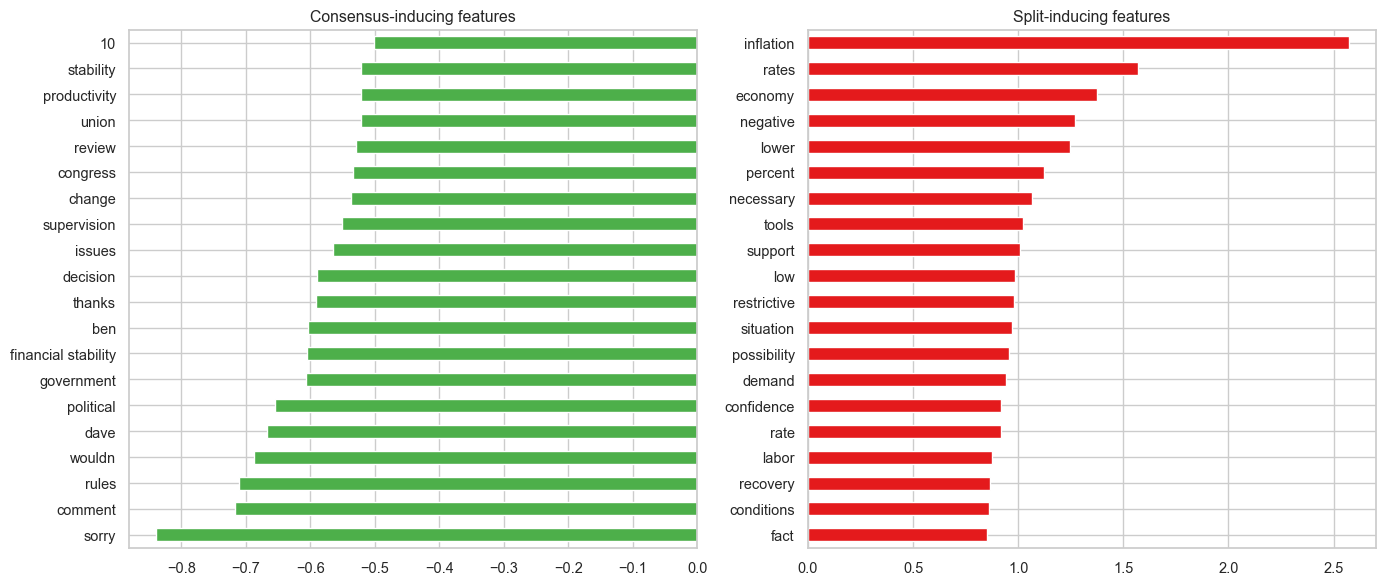

In [11]:
split_tfidf = baseline_results[("split", "TF-IDF")]
tfidf_vec = split_tfidf["estimator"].named_steps["tfidf"]
tfidf_logit = split_tfidf["estimator"].named_steps["logit"]
coef = pd.Series(tfidf_logit.coef_[0], index=tfidf_vec.get_feature_names_out()).sort_values()

top_consensus = coef.head(20).rename("coef").to_frame()
top_split = coef.tail(20).sort_values(ascending=False).rename("coef").to_frame()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_consensus.sort_values("coef").plot.barh(ax=axes[0], legend=False, color="#4daf4a")
axes[0].set_title("Consensus-inducing features")
top_split.sort_values("coef").plot.barh(ax=axes[1], legend=False, color="#e41a1c")
axes[1].set_title("Split-inducing features")
plt.tight_layout()
plt.show()

## 9. Meeting-level aggregation for the continuous targets

In [12]:
tfidf_pdir = baseline_results[("p_directional", "TF-IDF")]
tfidf_std3 = baseline_results[("score_std_3way", "TF-IDF")]
tfidf_std5 = baseline_results[("score_std_5way", "TF-IDF")]

test_eval = test_df[meta_cols + ["split", "p_directional", "score_std_3way", "score_std_5way"]].copy()
test_eval["pred_split_tfidf"] = baseline_results[("split", "TF-IDF")]["pred"]
test_eval["pred_p_directional_tfidf"] = tfidf_pdir["pred"]
test_eval["pred_score_std_3way_tfidf"] = tfidf_std3["pred"]
test_eval["pred_score_std_5way_tfidf"] = tfidf_std5["pred"]

meeting_eval = (
    test_eval.groupby(["bank", "doc_id"], as_index=False)
    .agg(
        actual_split_rate=("split", "mean"),
        pred_split_rate=("pred_split_tfidf", "mean"),
        actual_p_directional=("p_directional", "mean"),
        pred_p_directional=("pred_p_directional_tfidf", "mean"),
        actual_score_std_3way=("score_std_3way", "mean"),
        pred_score_std_3way=("pred_score_std_3way_tfidf", "mean"),
        actual_score_std_5way=("score_std_5way", "mean"),
        pred_score_std_5way=("pred_score_std_5way_tfidf", "mean"),
        n_turns=("turn_uid", "size"),
    )
)

meeting_summary = pd.DataFrame(
    [
        {
            "target": "p_directional",
            "turn_spearman": spearmanr(test_eval["p_directional"], test_eval["pred_p_directional_tfidf"]).statistic,
            "meeting_spearman": spearmanr(meeting_eval["actual_p_directional"], meeting_eval["pred_p_directional"]).statistic,
        },
        {
            "target": "score_std_3way",
            "turn_spearman": spearmanr(test_eval["score_std_3way"], test_eval["pred_score_std_3way_tfidf"]).statistic,
            "meeting_spearman": spearmanr(meeting_eval["actual_score_std_3way"], meeting_eval["pred_score_std_3way"]).statistic,
        },
        {
            "target": "score_std_5way",
            "turn_spearman": spearmanr(test_eval["score_std_5way"], test_eval["pred_score_std_5way_tfidf"]).statistic,
            "meeting_spearman": spearmanr(meeting_eval["actual_score_std_5way"], meeting_eval["pred_score_std_5way"]).statistic,
        },
    ]
)
display(meeting_summary.style.format({"turn_spearman": "{:.3f}", "meeting_spearman": "{:.3f}"}))

,target,turn_spearman,meeting_spearman
0,p_directional,0.646,0.718
1,score_std_3way,0.398,0.592
2,score_std_5way,0.511,0.789


## 9b. Truncation diagnostic before the transformer runs

Because the transformer section truncates to a fixed token limit, we should check:

1. how often turns exceed the token cap, by bank
2. whether disagreement is mechanically higher among truncated turns

This helps distinguish genuine linguistic ambiguity from a length / clipping confound.

By bank


,bank,n_turns,mean_tokens,median_tokens,p95_tokens,trunc_rate_256,split_rate,mean_p_directional,mean_std3,mean_std5
0,BoE,895,289.6,271.0,631.0,54.1%,25.3%,0.172,0.126,0.145
1,ECB,1163,317.3,278.0,733.1,54.6%,33.0%,0.258,0.166,0.208
2,Fed,1914,255.4,231.0,569.3,44.1%,33.2%,0.260,0.171,0.210


Truncated vs non-truncated


,truncated_256,n_turns,mean_tokens,split_rate,mean_p_directional,mean_std3,mean_std5
0,Not truncated,2009,136.4,23.9%,0.180,0.124,0.153
1,Truncated,1963,429.4,39.0%,0.300,0.195,0.237


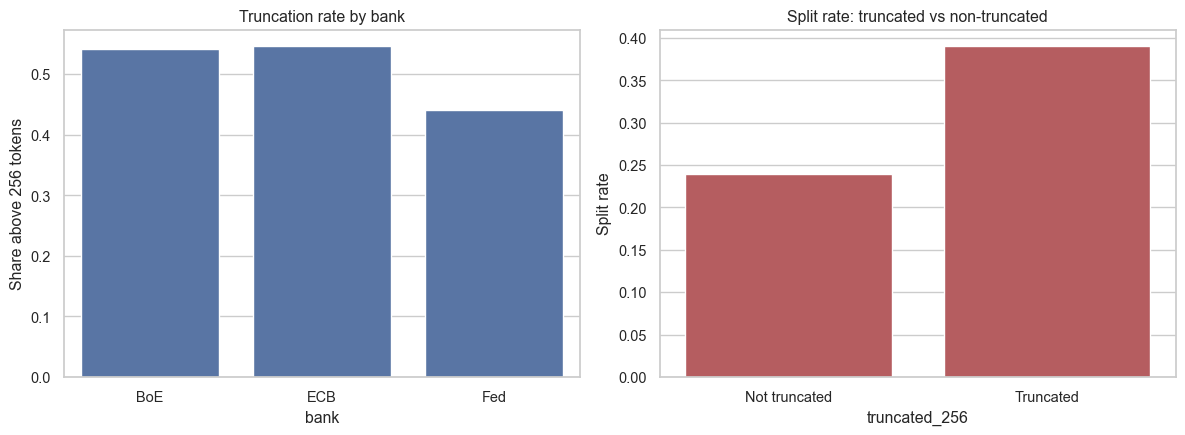

In [13]:
from transformers import AutoTokenizer

TRUNC_MODEL_NAME = "microsoft/deberta-v3-base"
TRUNC_MAX_LEN = 256
trunc_tokenizer = AutoTokenizer.from_pretrained(TRUNC_MODEL_NAME)

def token_count(text: str) -> int:
    enc = trunc_tokenizer(
        str(text),
        truncation=False,
        padding=False,
        return_attention_mask=False,
        return_token_type_ids=False,
    )
    return len(enc["input_ids"])

trunc_df = disagreement[["turn_uid", "bank", "doc_id", "text", "split", "p_directional", "score_std_3way", "score_std_5way"]].copy()
trunc_df["token_count"] = trunc_df["text"].astype(str).apply(token_count)
trunc_df["truncated_256"] = trunc_df["token_count"] > TRUNC_MAX_LEN

trunc_by_bank = (
    trunc_df.groupby("bank", as_index=False)
    .agg(
        n_turns=("turn_uid", "size"),
        mean_tokens=("token_count", "mean"),
        median_tokens=("token_count", "median"),
        p95_tokens=("token_count", lambda s: float(np.percentile(s, 95))),
        trunc_rate_256=("truncated_256", "mean"),
        split_rate=("split", "mean"),
        mean_p_directional=("p_directional", "mean"),
        mean_std3=("score_std_3way", "mean"),
        mean_std5=("score_std_5way", "mean"),
    )
)
print("By bank")
display(trunc_by_bank.style.format({
    "mean_tokens": "{:.1f}",
    "median_tokens": "{:.1f}",
    "p95_tokens": "{:.1f}",
    "trunc_rate_256": "{:.1%}",
    "split_rate": "{:.1%}",
    "mean_p_directional": "{:.3f}",
    "mean_std3": "{:.3f}",
    "mean_std5": "{:.3f}",
}))

trunc_compare = (
    trunc_df.groupby("truncated_256", as_index=False)
    .agg(
        n_turns=("turn_uid", "size"),
        mean_tokens=("token_count", "mean"),
        split_rate=("split", "mean"),
        mean_p_directional=("p_directional", "mean"),
        mean_std3=("score_std_3way", "mean"),
        mean_std5=("score_std_5way", "mean"),
    )
)
trunc_compare["truncated_256"] = trunc_compare["truncated_256"].map({False: "Not truncated", True: "Truncated"})
print("Truncated vs non-truncated")
display(trunc_compare.style.format({
    "mean_tokens": "{:.1f}",
    "split_rate": "{:.1%}",
    "mean_p_directional": "{:.3f}",
    "mean_std3": "{:.3f}",
    "mean_std5": "{:.3f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=trunc_by_bank, x="bank", y="trunc_rate_256", ax=axes[0], color="#4C72B0")
axes[0].set_title("Truncation rate by bank")
axes[0].set_ylabel("Share above 256 tokens")

sns.barplot(data=trunc_compare, x="truncated_256", y="split_rate", ax=axes[1], color="#C44E52")
axes[1].set_title("Split rate: truncated vs non-truncated")
axes[1].set_ylabel("Split rate")

plt.tight_layout()
plt.show()

## 10. DeBERTa / BERT experiments for all four targets

This section is meant for Colab or another GPU environment.

Target mapping:

- `split` -> binary classification
- `p_directional` -> regression
- `score_std_3way` -> regression
- `score_std_5way` -> regression

Optional ablation:

- **Frozen generic encoder**: does broad contextual encoding already contain disagreement signal?
- **Fine-tuned DeBERTa on your disagreement targets**: does direct supervision on disagreement help?
- **Frozen FOMC-RoBERTa stance model**: does a domain-specific hawkish / dovish / neutral encoder already carry disagreement signal before direct disagreement supervision?

Intuition:

- frozen DeBERTa = generic contextual encoding
- frozen FOMC-RoBERTa = domain + stance encoding
- fine-tuned DeBERTa = disagreement-target supervision

So FOMC-RoBERTa is a useful middle ablation: stronger than a generic base model, but still not directly trained on your disagreement targets.

In [14]:
RUN_BERT = False

if RUN_BERT:
    # In Colab, install if needed:
    # !pip install -q transformers sentencepiece

    import os
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    from transformers import AutoModel, AutoTokenizer

    MODEL_NAME = "microsoft/deberta-v3-base"
    FOMC_ROBERTA_NAME = "gtfintechlab/FOMC-RoBERTa"
    MAX_LEN = 256
    BATCH_SIZE = 8
    EPOCHS = 3
    LR = 1e-5
    HEAD_LR = 1e-3
    GRAD_ACC = 4
    SAVE_BERT_MODELS = True
    LOAD_BERT_MODELS_IF_AVAILABLE = True
    FORCE_RETRAIN_TARGETS = set()
    CHECKPOINT_DIR = ROOT / "output" / "stance" / "bert_checkpoints"
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    # For the gated HF model, set your token in Colab before loading:
    # os.environ["HF_TOKEN"] = "hf_..."
    HF_TOKEN = os.environ.get("HF_TOKEN")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    print("Checkpoint dir:", CHECKPOINT_DIR)

    if SPLIT_PATH.exists():
        split_map = pd.read_csv(SPLIT_PATH)
        split_lookup = dict(zip(split_map["doc_id"], split_map["split"]))
        bert_df = disagreement.copy()
        bert_df["split_set"] = bert_df["doc_id"].map(split_lookup)
    else:
        bert_df = disagreement.copy()
        bert_df["split_set"] = bert_df["doc_id"].apply(lambda x: "test" if x in test_doc_ids else "train")

    bert_train = bert_df[bert_df["split_set"] == "train"].reset_index(drop=True)
    bert_test = bert_df[bert_df["split_set"] == "test"].reset_index(drop=True)

    target_task_type = {
        "split": "classification",
        "p_directional": "regression",
        "score_std_3way": "regression",
        "score_std_5way": "regression",
    }

    bert_models = {}
    bert_tokenizers = {}
    bert_checkpoint_paths = {}

    class TextTargetDataset(Dataset):
        def __init__(self, df, tokenizer, target_col, task_type, max_length=256):
            clean = df[["text", target_col]].copy()
            clean = clean.replace([np.inf, -np.inf], np.nan).dropna(subset=[target_col]).reset_index(drop=True)
            self.df = clean
            self.tokenizer = tokenizer
            self.target_col = target_col
            self.task_type = task_type
            self.max_length = max_length

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            enc = self.tokenizer(
                str(row["text"]),
                max_length=self.max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )
            item = {
                "input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
            }
            if self.task_type == "classification":
                item["labels"] = torch.tensor(int(row[self.target_col]), dtype=torch.long)
            else:
                item["labels"] = torch.tensor(float(row[self.target_col]), dtype=torch.float32)
            return item

    class EncoderWithHead(nn.Module):
        def __init__(self, encoder_name, task_type, token=None):
            super().__init__()
            self.encoder = AutoModel.from_pretrained(encoder_name, token=token)
            hidden_size = self.encoder.config.hidden_size
            self.task_type = task_type
            out_dim = 2 if task_type == "classification" else 1
            self.head = nn.Linear(hidden_size, out_dim)

        def forward(self, input_ids, attention_mask):
            enc = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
            cls = enc.last_hidden_state[:, 0, :].float()
            out = self.head(cls)
            return out, cls

    def make_loaders(tokenizer, target_col, task_type):
        train_ds = TextTargetDataset(bert_train, tokenizer, target_col, task_type, MAX_LEN)
        test_ds = TextTargetDataset(bert_test, tokenizer, target_col, task_type, MAX_LEN)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
        return train_ds, test_ds, train_loader, test_loader

    def make_opt(model, enc_lr=1e-5, head_lr=1e-3):
        return torch.optim.AdamW(
            [
                {"params": model.encoder.parameters(), "lr": enc_lr, "weight_decay": 0.01},
                {"params": model.head.parameters(), "lr": head_lr, "weight_decay": 0.01},
            ]
        )

    def compute_target_metrics(task_type, y_true, pred):
        y_true = np.asarray(y_true)
        pred = np.asarray(pred)
        mask = np.isfinite(y_true) & np.isfinite(pred)
        y_true = y_true[mask]
        pred = pred[mask]
        if len(y_true) == 0:
            return {"headline_metric": np.nan, "secondary_metric": np.nan}
        if task_type == "classification":
            if len(np.unique(y_true)) < 2:
                return {"headline_metric": np.nan, "secondary_metric": np.nan}
            return {
                "headline_metric": roc_auc_score(y_true, pred),
                "secondary_metric": average_precision_score(y_true, pred),
            }
        rho = spearmanr(y_true, pred).statistic
        return {
            "headline_metric": float(rho) if not math.isnan(rho) else np.nan,
            "secondary_metric": r2_score(y_true, pred),
        }

    @torch.no_grad()
    def evaluate_model(model, loader, task_type, loss_fn):
        model.eval()
        preds = []
        labels = []
        losses = []
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            y = batch["labels"].to(device)
            out, _ = model(ids, mask)
            if task_type == "classification":
                loss = loss_fn(out, y)
                pred = torch.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
            else:
                out = out.squeeze(-1)
                loss = loss_fn(out, y)
                pred = out.detach().cpu().numpy()
            losses.append(loss.item())
            preds.extend(pred.tolist())
            labels.extend(y.detach().cpu().numpy().tolist())
        metrics = compute_target_metrics(task_type, labels, preds)
        metrics["loss"] = float(np.mean(losses)) if losses else np.nan
        return metrics, np.asarray(preds), np.asarray(labels)

    def checkpoint_path_for(model_label, target_col):
        safe_model = model_label.replace("/", "_")
        return CHECKPOINT_DIR / f"{safe_model}_{target_col}.pt"

    def save_checkpoint(model, tokenizer, target_col, model_label, task_type, metrics):
        path = checkpoint_path_for(model_label, target_col)
        payload = {
            "model_state_dict": model.state_dict(),
            "model_name": model_label,
            "target_col": target_col,
            "task_type": task_type,
            "max_len": MAX_LEN,
            "metrics": metrics,
        }
        torch.save(payload, path)
        tokenizer.save_pretrained(path.with_suffix(""))
        bert_checkpoint_paths[target_col] = path
        print(f"Saved checkpoint -> {path}")
        print(f"Saved tokenizer dir -> {path.with_suffix('')}")
        return path

    def load_checkpoint(target_col, model_label=MODEL_NAME, token=None):
        path = checkpoint_path_for(model_label, target_col)
        tok_dir = path.with_suffix("")
        if not path.exists():
            return None
        if not tok_dir.exists():
            print(f"Checkpoint found for {target_col}, but tokenizer dir is missing: {tok_dir}")
            return None

        ckpt = torch.load(path, map_location=device)
        task_type = ckpt["task_type"]
        tokenizer = AutoTokenizer.from_pretrained(tok_dir, token=token)
        model = EncoderWithHead(model_label, task_type, token=token).to(device).float()
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        bert_models[target_col] = model
        bert_tokenizers[target_col] = tokenizer
        bert_checkpoint_paths[target_col] = path
        print(f"Loaded checkpoint <- {path}")
        return {
            "model": model,
            "tokenizer": tokenizer,
            "task_type": task_type,
            "metrics": ckpt.get("metrics", {}),
            "path": path,
        }

    def run_finetuned_target(target_col, model_name=MODEL_NAME, token=None):
        task_type = target_task_type[target_col]
        load_from_disk = LOAD_BERT_MODELS_IF_AVAILABLE and target_col not in FORCE_RETRAIN_TARGETS
        loaded = load_checkpoint(target_col, model_label=model_name, token=token) if load_from_disk else None
        if loaded is not None:
            tokenizer = loaded["tokenizer"]
            model = loaded["model"]
            _, _, _, test_loader = make_loaders(tokenizer, target_col, task_type)
            loss_fn = nn.CrossEntropyLoss() if task_type == "classification" else nn.MSELoss()
            eval_metrics, pred, labels = evaluate_model(model, test_loader, task_type, loss_fn)
            metrics = {**loaded.get("metrics", {}), **eval_metrics}
            return model, tokenizer, metrics, pred, labels, "loaded"

        tokenizer = AutoTokenizer.from_pretrained(model_name, token=token)
        _, _, train_loader, test_loader = make_loaders(tokenizer, target_col, task_type)
        model = EncoderWithHead(model_name, task_type, token=token).to(device).float()
        loss_fn = nn.CrossEntropyLoss() if task_type == "classification" else nn.MSELoss()

        for epoch in range(1, EPOCHS + 1):
            for p in model.encoder.parameters():
                p.requires_grad = (epoch > 1)
            opt = make_opt(model, enc_lr=(LR if epoch > 1 else 0.0), head_lr=HEAD_LR)
            model.train()
            opt.zero_grad()
            running_loss = 0.0
            for step, batch in enumerate(train_loader, 1):
                ids = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                y = batch["labels"].to(device)
                out, _ = model(ids, mask)
                if task_type == "classification":
                    loss = loss_fn(out, y) / GRAD_ACC
                else:
                    loss = loss_fn(out.squeeze(-1), y) / GRAD_ACC
                loss.backward()
                running_loss += loss.item() * GRAD_ACC
                if step % GRAD_ACC == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    opt.zero_grad()
            eval_metrics, pred, labels = evaluate_model(model, test_loader, task_type, loss_fn)
            print(
                f"{target_col} | epoch {epoch} | "
                f"train_loss={running_loss/max(len(train_loader),1):.4f} | "
                f"test_metric={eval_metrics['headline_metric']:.3f}"
            )
        bert_models[target_col] = model
        bert_tokenizers[target_col] = tokenizer
        if SAVE_BERT_MODELS:
            save_checkpoint(model, tokenizer, target_col, model_name, task_type, eval_metrics)
        return model, tokenizer, eval_metrics, pred, labels, "trained"

    @torch.no_grad()
    def extract_cls_embeddings(model_name, texts_train, texts_test, token=None):
        tok = AutoTokenizer.from_pretrained(model_name, token=token)
        encoder = AutoModel.from_pretrained(model_name, token=token).to(device)
        encoder.eval()

        def encode_texts(texts):
            outs = []
            for start in range(0, len(texts), BATCH_SIZE):
                batch_texts = texts[start:start + BATCH_SIZE]
                enc = tok(
                    batch_texts,
                    truncation=True,
                    padding=True,
                    max_length=MAX_LEN,
                    return_tensors="pt",
                )
                enc = {k: v.to(device) for k, v in enc.items() if k in {"input_ids", "attention_mask"}}
                out = encoder(**enc)
                cls = out.last_hidden_state[:, 0, :].detach().cpu().numpy()
                outs.append(cls)
            return np.vstack(outs)

        Xtr = encode_texts(texts_train)
        Xte = encode_texts(texts_test)
        return Xtr, Xte

    def run_frozen_encoder_ablation(model_label, Xtr, Xte):
        rows = []
        for target, task_type in target_task_type.items():
            if task_type == "classification":
                sc = StandardScaler()
                Xtr_s = sc.fit_transform(Xtr)
                Xte_s = sc.transform(Xte)
                clf = LogisticRegression(max_iter=5000, class_weight="balanced", C=1.0)
                clf.fit(Xtr_s, train_df[target].values)
                pred = clf.predict_proba(Xte_s)[:, 1]
                rows.append(
                    {
                        "target": target,
                        "model": model_label,
                        "headline_metric": roc_auc_score(test_df[target].values, pred),
                        "secondary_metric": average_precision_score(test_df[target].values, pred),
                    }
                )
            else:
                sc = StandardScaler()
                Xtr_s = sc.fit_transform(Xtr)
                Xte_s = sc.transform(Xte)
                reg = Ridge(alpha=1.0).fit(Xtr_s, train_df[target].values)
                pred = reg.predict(Xte_s)
                rows.append(
                    {
                        "target": target,
                        "model": model_label,
                        "headline_metric": spearmanr(test_df[target].values, pred).statistic,
                        "secondary_metric": r2_score(test_df[target].values, pred),
                    }
                )
        return pd.DataFrame(rows)

    bert_rows = []
    bert_preds = {}
    for target in ["split", "p_directional", "score_std_3way", "score_std_5way"]:
        model, tokenizer, metrics, pred, labels, source = run_finetuned_target(target, MODEL_NAME, token=None)
        bert_models[target] = model
        bert_tokenizers[target] = tokenizer
        bert_rows.append(
            {
                "target": target,
                "model": "DeBERTa",
                "source": source,
                "headline_metric": metrics["headline_metric"],
                "secondary_metric": metrics["secondary_metric"],
            }
        )
        bert_preds[target] = pred
    bert_results = pd.DataFrame(bert_rows)
    display(bert_results.style.format({"headline_metric": "{:.3f}", "secondary_metric": "{:.3f}"}))

    if "split" in bert_models:
        model = bert_models["split"]
        tokenizer = bert_tokenizers["split"]
        print("Bound `model` and `tokenizer` to the split checkpoint for immediate DCR use.")

    RUN_FROZEN_ABLATIONS = False
    if RUN_FROZEN_ABLATIONS:
        train_texts = train_df["text"].astype(str).tolist()
        test_texts = test_df["text"].astype(str).tolist()

        # 1. Frozen generic encoder.
        Xtr_deb, Xte_deb = extract_cls_embeddings(MODEL_NAME, train_texts, test_texts, token=None)
        frozen_deberta_results = run_frozen_encoder_ablation("Frozen DeBERTa", Xtr_deb, Xte_deb)

        # 2. Frozen FOMC-RoBERTa stance encoder.
        # Hugging Face model card: gated model; requires accepted access + HF token.
        Xtr_fomc, Xte_fomc = extract_cls_embeddings(FOMC_ROBERTA_NAME, train_texts, test_texts, token=HF_TOKEN)
        frozen_fomc_results = run_frozen_encoder_ablation("Frozen FOMC-RoBERTa", Xtr_fomc, Xte_fomc)

        ablation_table = pd.concat([frozen_deberta_results, frozen_fomc_results, bert_results], ignore_index=True)
        print("Ablation comparison: frozen generic vs frozen stance encoder vs fine-tuned disagreement model")
        display(ablation_table.style.format({"headline_metric": "{:.3f}", "secondary_metric": "{:.3f}"}))
else:
    print("BERT section is ready for Colab/GPU. Set RUN_BERT=True there.")

BERT section is ready for Colab/GPU. Set RUN_BERT=True there.


## 11. Final framing

The comparison now has a simple benchmark ladder:

1. Loughran-McDonald style generic sentiment
2. simple central-bank stance dictionary
3. Parle-style monetary-policy dictionary
4. TF-IDF
5. DeBERTa

And the targets separate:

- **boundary disagreement**: `split`, `p_directional`
- **collapsed stance instability**: `score_std_3way`
- **full-label instability**: `score_std_5way`